In [1]:
!pip install opencv-python

In [2]:
import numpy as np
import pandas as pd
from tensorflow import keras
import cv2
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
import tensorflow as tf
print(tf.executing_eagerly())

True


In [5]:
df = pd.read_csv("train.csv/train.csv")
base_path="./imagess/images_000"

In [6]:
import glob

# Get all actual image paths you have on disk
all_images = glob.glob(os.path.join(base_path, "*", "*", "*", "*.jpg"))
existing_ids = set(os.path.splitext(os.path.basename(p))[0] for p in all_images)

print("Images found on disk:", len(existing_ids))

df = df[df['id'].isin(existing_ids)].reset_index(drop=True)
print("Rows remaining after filtering:", len(df))

Images found on disk: 8266
Rows remaining after filtering: 3147


In [7]:
df

,id,landmark_id
0,00024ea6140f4221,136
1,0064acfa759f4153,192
2,007ff8952d3bbb20,389
3,002cf77393f82b81,392
4,002d022dd6eff825,392
...,...,...
3142,002bd182efc32595,202723
3143,00149309c59d185f,202752
3144,0064ecfae82480a0,202886
3145,0006bd092b119041,202939


In [8]:
samples = 20000
df = df.loc[df["id"].astype(str).str.startswith('00',na=False),:]
num_classes = len(df["landmark_id"].unique())
num_data = len(df)

In [9]:
num_classes

2916

In [10]:
num_data

3147

In [11]:
data = pd.DataFrame(df["landmark_id"].value_counts())

data.reset_index(inplace = True)
data.head()

,landmark_id,count
0,138982,16
1,83144,8
2,126637,5
3,152708,4
4,194914,4


In [12]:
data.tail()

,landmark_id,count
2911,70088,1
2912,70134,1
2913,70173,1
2914,70265,1
2915,202972,1


In [13]:
data.columns=['landmark_id','count']

In [14]:
data['count'].describe()

count    2916.000000
mean        1.079218
std         0.432275
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        16.000000
Name: count, dtype: float64

(array([2.915e+03, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

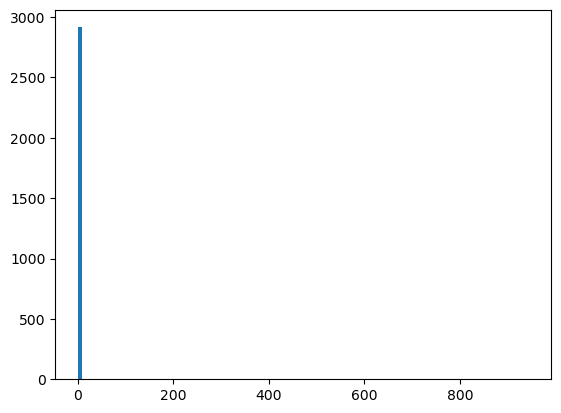

In [15]:
plt.hist(data['count'],100,range = (0,944),label = 'test')

In [16]:
data['count'].between(0,5).sum()

np.int64(2914)

In [17]:
data['count'].between(5,10).sum()

np.int64(2)

(array([1., 1., 1., ..., 1., 1., 2.], shape=(2915,)),
 array([1.36000e+02, 1.92000e+02, 3.89000e+02, ..., 2.02886e+05,
        2.02939e+05, 2.02972e+05], shape=(2916,)),
 <BarContainer object of 2915 artists>)

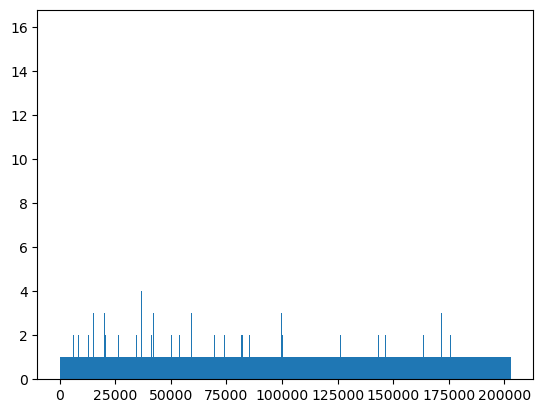

In [18]:
plt.hist(df["landmark_id"],bins=df["landmark_id"].unique())

In [19]:
from sklearn.preprocessing import LabelEncoder
lencoder = LabelEncoder()
lencoder.fit(df["landmark_id"])

LabelEncoder()

In [20]:
df.head

<bound method NDFrame.head of                     id  landmark_id
0     00024ea6140f4221          136
1     0064acfa759f4153          192
2     007ff8952d3bbb20          389
3     002cf77393f82b81          392
4     002d022dd6eff825          392
...                ...          ...
3142  002bd182efc32595       202723
3143  00149309c59d185f       202752
3144  0064ecfae82480a0       202886
3145  0006bd092b119041       202939
3146  001e45514ceb27c9       202972

[3147 rows x 2 columns]>

In [21]:
def encode_label(lbl):
    return lencoder.transform(lbl)

In [22]:
def decode_label(lbl):
    return lencoder.inverse_transform(lbl)

In [23]:
def get_image_from_number(n):
    fname, label = df.iloc[n]

    fname = fname + ".jpg"

    f1 = fname[0]
    f2 = fname[1]
    f3 = fname[2]

    path = os.path.join(f1, f2, f3, fname)
    full_path = os.path.join(base_path, path)

    # print("FULL PATH:", full_path)
    # print("EXISTS:", os.path.exists(full_path))

    im = cv2.imread(full_path)

    return im, label

4 Sample images from random classes


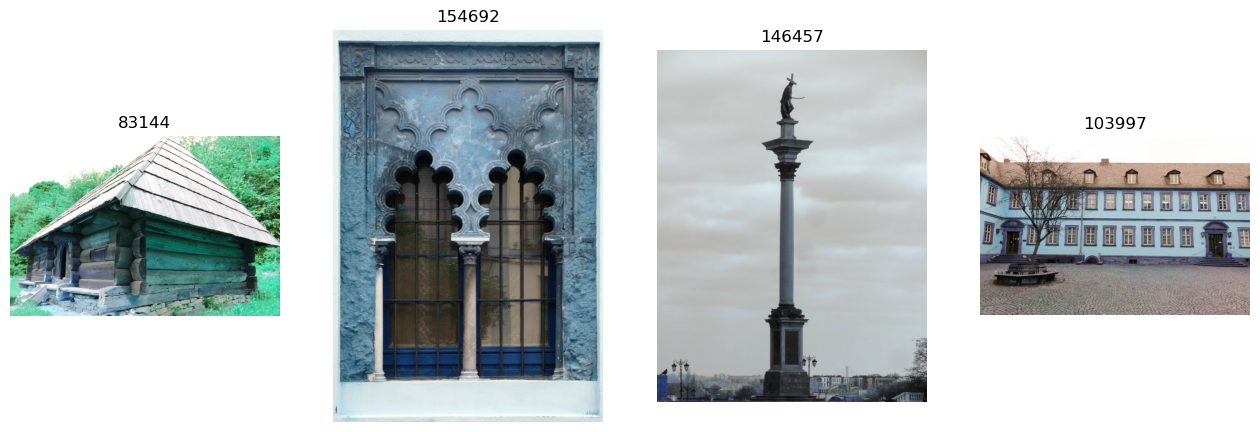

In [24]:
print("4 Sample images from random classes")
fig = plt.figure(figsize=(16,16))
for i in range(1, 5):
    n = random.randint(0, len(df) - 1)
    img, label = get_image_from_number(n)
    fig.add_subplot(1, 4, i)
    plt.imshow(img)
    plt.axis('off')
    plt.title(str(label))
plt.show()

In [25]:
import tensorflow as tf
from keras.applications.vgg19 import VGG19
from keras.layers import *
from keras import Sequential
#tf.compat.v1.disable_eager_execution()

In [26]:
learning_rate = 0.0001
decay_speed = 1e-6
momemtum = 0.09
loss_function = "sparse_categorical_crossentropy"
source_model = VGG19(weights= None)
drop_layer = Dropout(0.5)
drop_layer2 = Dropout(0.5)

In [27]:
model = Sequential()
for layer in source_model.layers[:-1]:
    if layer == source_model.layers[-25]:
       model.add(BatchNormalization())
    model.add(layer)
model.add(Dense(num_classes, activation = "softmax"))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization                  │ (None, 224, 224, 3)         │              12 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,8

 Total params: 151,517,104 (577.99 MB)

 Trainable params: 151,517,098 (577.99 MB)

 Non-trainable params: 6 (24.00 B)

In [28]:
optim1 = keras.optimizers.RMSprop(learning_rate = learning_rate)
model.compile(optimizer = optim1,
             loss = loss_function,
             metrics = ["accuracy"])

In [29]:
def image_reshape(im, target_size):
    return cv2.resize(im,target_size)

In [30]:
def get_batch(dataframe, start, batch_size):
    image_array = []
    label_array = []

    end_img = start+batch_size
    if(end_img) > len(dataframe):
         end_img =  len(dataframe)

    for idx in range(start, end_img):
         n = idx
         im, label = get_image_from_number(n)
         im = image_reshape(im, (224, 224)) / 255.0
         image_array.append(im)
         label_array.append(label)
     
    label_array = encode_label(label_array)

    return np.array(image_array), np.array(label_array)

In [31]:
batch_size = 16
epoch_shuffle = True
weight_classes = True
epochs = 1

train,val = np.split(df.sample(frac=1),[int(0.8*len(df))])
print(len(train))
print(len(val))

2517
630


C:\Users\spand\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [32]:
for e in range(epochs):
    print("Epoch:" + str (e+1) + "/"+ str(epochs))
    if epoch_shuffle:
        train = train.sample(n = 50,random_state=42)
    for it in range(int(np.ceil(len(train)/batch_size))):
        X_train, y_train = get_batch(train, it*batch_size, batch_size)

        model.train_on_batch(X_train, y_train)

model.save("Model.keras")

Epoch:1/1


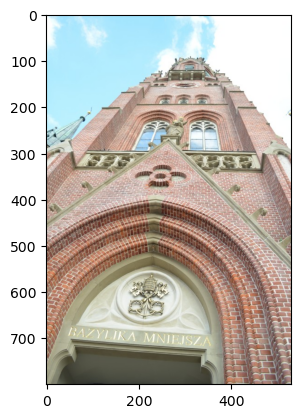

In [36]:
batch_size = 16
errors = 0
good_preds = []
bad_preds = []

for it in range(int(np.ceil(len(val)/batch_size))):
    X_val, y_val = get_batch(val, it * batch_size, batch_size)

    X_val = np.array(X_val)
    result = model.predict(X_val, verbose=0)
    cla = np.argmax(result, axis=1)
    for idx, res in enumerate(result):
        if cla[idx] != y_val[idx]:
            errors = errors + 1
            bad_preds.append([batch_size*it + idx, cla[idx], res[cla[idx]]])
        else:
            good_preds.append([batch_size*it + idx, cla[idx], res[cla[idx]]])

for i in range(min(5,len(good_preds))):
    n = int(good_preds[i][0])
    img, lbl = get_image_from_number(n)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()